# Assignment 5: Classification Fine-tuning (Option A)


## 1. Import Required Libraries and Set Device

In [34]:
# Standard library imports
import os
import json
import time
import zipfile
from pathlib import Path

# Data processing
import numpy as np
import pandas as pd
import requests

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Tokenization
import tiktoken

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Progress bar
from tqdm import tqdm

# Set random seeds for reproducibility
SEED = 123
torch.manual_seed(SEED)
np.random.seed(SEED)

# Set device - use GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use MPS on Apple Silicon (requires PyTorch 2.0+)
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Print library versions
print(f"\nLibrary versions:")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

Using device: cuda

Library versions:
PyTorch: 2.5.1+cu121
NumPy: 1.26.4
Pandas: 2.3.2


## 2. Define GPT Model Architecture

In [35]:
# =============================================================================
# Multi-Head Attention with Causal Masking
# =============================================================================
class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention mechanism with causal masking.
    
    Causal masking ensures each position can only attend to previous positions,
    which is essential for autoregressive language modeling.
    """
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        
        # Linear projections for Q, K, V
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        
        # Output projection
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        
        # Causal mask (upper triangular)
        self.register_buffer(
            "mask", 
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
    
    def forward(self, x):
        batch_size, num_tokens, d_in = x.shape
        
        # Compute Q, K, V
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        # Reshape for multi-head attention
        keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
        values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
        
        # Transpose for batch matrix multiplication
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)
        
        # Scaled dot-product attention
        attn_scores = queries @ keys.transpose(2, 3)
        
        # Apply causal mask
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        # Softmax and dropout
        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Compute weighted sum
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.reshape(batch_size, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)
        
        return context_vec


# =============================================================================
# Layer Normalization
# =============================================================================
class LayerNorm(nn.Module):
    """Layer Normalization for training stability."""
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


# =============================================================================
# GELU Activation Function
# =============================================================================
class GELU(nn.Module):
    """
    GELU activation: x * Φ(x), approximated using tanh.
    Used in GPT and many modern transformers instead of ReLU.
    """
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))


# =============================================================================
# Feed-Forward Network
# =============================================================================
class FeedForward(nn.Module):
    """
    Position-wise FFN with expansion factor of 4.
    Structure: Linear -> GELU -> Linear
    """
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )
    
    def forward(self, x):
        return self.layers(x)


# =============================================================================
# Transformer Block
# =============================================================================
class TransformerBlock(nn.Module):
    """
    Single transformer block: LayerNorm -> Attention -> Residual -> LayerNorm -> FFN -> Residual
    Uses pre-norm variant for better training stability.
    """
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_resid = nn.Dropout(cfg["drop_rate"])
    
    def forward(self, x):
        # Attention block with residual
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_resid(x)
        x = x + shortcut
        
        # FFN block with residual
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_resid(x)
        x = x + shortcut
        
        return x


# =============================================================================
# Complete GPT Model
# =============================================================================
class GPTModel(nn.Module):
    """
    Complete GPT model with token embeddings, positional embeddings,
    transformer blocks, and output projection.
    """
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        
        # Embeddings
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        
        # Transformer blocks
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        
        # Output projection
        logits = self.out_head(x)
        return logits


print("GPT Model architecture defined successfully!")

GPT Model architecture defined successfully!


## 3. Implement Classification Head Modification

In [36]:
def modify_model_for_classification(model, num_classes, emb_dim, freeze_base=True):
    """
    Modify a pretrained GPT model for classification.
    
    Args:
        model: Pretrained GPTModel
        num_classes: Number of output classes (2 for spam classification)
        emb_dim: Embedding dimension of the model
        freeze_base: If True, freeze all layers except the classification head
        
    Returns:
        Modified model ready for classification
    """
    # Optionally freeze all base model parameters
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False
    
    # Replace the output head with a classification head
    # This layer will be trainable by default
    model.out_head = nn.Linear(in_features=emb_dim, out_features=num_classes)
    
    # If we want better performance, also unfreeze the last transformer block
    # and the final layer norm
    if freeze_base:
        # Unfreeze last transformer block
        for param in model.trf_blocks[-1].parameters():
            param.requires_grad = True
        
        # Unfreeze final layer norm
        for param in model.final_norm.parameters():
            param.requires_grad = True
    
    return model


def count_trainable_parameters(model):
    """Count total and trainable parameters in a model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Trainable: {100 * trainable_params / total_params:.2f}%")
    
    return total_params, trainable_params


print("Classification modification functions defined!")

Classification modification functions defined!


## 4. Load and Prepare Spam Classification Dataset
- Class imbalance: ~87% ham, ~13% spam

In [37]:
# Define download function
def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    """Download and extract the SMS Spam Collection dataset."""
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download.")
        return

    # Download the file
    print(f"Downloading dataset from {url}...")
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzip
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Rename to .tsv extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"Dataset saved to {data_file_path}")


# Download dataset
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
backup_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except Exception as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    download_and_unzip_spam_data(backup_url, zip_path, extracted_path, data_file_path)

print("Dataset download complete!")

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download.
Dataset download complete!


In [38]:
# Load the dataset
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])

print("Dataset loaded!")
print(f"Total samples: {len(df)}")
print(f"\nClass distribution (original):")
print(df["Label"].value_counts())

# Display sample entries
print("\n\nSample spam messages:")
print(df[df["Label"] == "spam"]["Text"].head(3).tolist())

print("\n\nSample ham messages:")
print(df[df["Label"] == "ham"]["Text"].head(3).tolist())

Dataset loaded!
Total samples: 5572

Class distribution (original):
Label
ham     4825
spam     747
Name: count, dtype: int64


Sample spam messages:
["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's", "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv", 'WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.']


Sample ham messages:
['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...', 'Ok lar... Joking wif u oni...', 'U dun say so early hor... U c already then say...']


In [39]:
# Create balanced dataset by downsampling the majority class
def create_balanced_dataset(df):
    """
    Balance the dataset by downsampling the majority class (ham) 
    to match the minority class (spam).
    """
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample ham instances to match spam count
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=SEED)
    
    # Combine
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    
    return balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)


balanced_df = create_balanced_dataset(df)

print("Balanced dataset created!")
print(f"Total samples: {len(balanced_df)}")
print(f"\nClass distribution (balanced):")
print(balanced_df["Label"].value_counts())

# Convert labels to numeric
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

print("\n\nNumeric labels:")
print(balanced_df["Label"].value_counts())

Balanced dataset created!
Total samples: 1494

Class distribution (balanced):
Label
ham     747
spam    747
Name: count, dtype: int64


Numeric labels:
Label
0    747
1    747
Name: count, dtype: int64


## 5. Create Data Preprocessing Pipeline

Padding token ID: 50256

Sequence length statistics:
  Min: 2
  Max: 120
  Mean: 30.6
  Median: 33.0


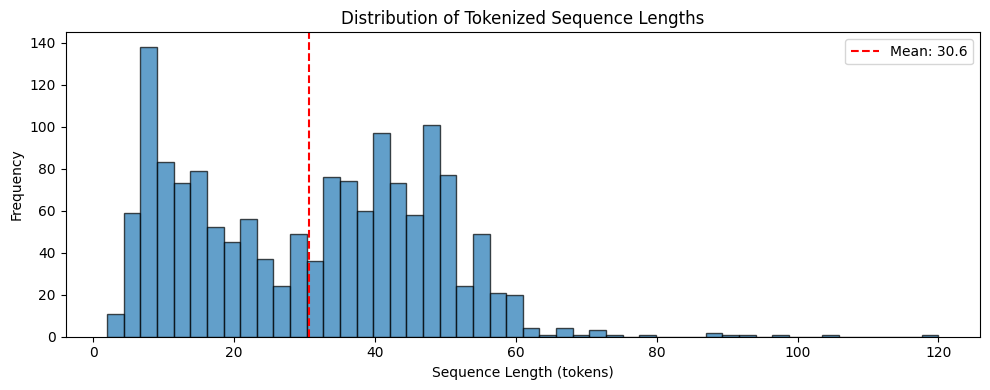

In [40]:
# Initialize tokenizer
tokenizer = tiktoken.get_encoding("gpt2")

# The padding token ID for GPT-2 is 50256 (<|endoftext|>)
PAD_TOKEN_ID = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
print(f"Padding token ID: {PAD_TOKEN_ID}")

# Analyze sequence lengths
sequence_lengths = [len(tokenizer.encode(text)) for text in balanced_df["Text"]]
print(f"\nSequence length statistics:")
print(f"  Min: {min(sequence_lengths)}")
print(f"  Max: {max(sequence_lengths)}")
print(f"  Mean: {np.mean(sequence_lengths):.1f}")
print(f"  Median: {np.median(sequence_lengths):.1f}")

# Visualize distribution
plt.figure(figsize=(10, 4))
plt.hist(sequence_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Frequency")
plt.title("Distribution of Tokenized Sequence Lengths")
plt.axvline(np.mean(sequence_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(sequence_lengths):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Build PyTorch Dataset and DataLoader

Train/Validation/Test splits (70%/10%/20%)



In [41]:
# Split data into train/validation/test sets
def random_split(df, train_frac, validation_frac):
    """Split DataFrame into train, validation, and test sets."""
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)
    
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    
    return train_df, validation_df, test_df


train_df, val_df, test_df = random_split(balanced_df, 0.7, 0.1)

# Save to CSV for later use
train_df.to_csv("train.csv", index=None)
val_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Train set size: 1045
Validation set size: 149
Test set size: 300


In [42]:
# Define SpamDataset class
class SpamDataset(Dataset):
    """
    PyTorch Dataset for spam classification.
    
    Handles tokenization, padding, and truncation of text data.
    """
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        
        # Pre-tokenize all texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]
        
        # Determine max length
        if max_length is None:
            self.max_length = max(len(et) for et in self.encoded_texts)
        else:
            self.max_length = max_length
            # Truncate longer sequences
            self.encoded_texts = [
                et[:self.max_length] for et in self.encoded_texts
            ]
        
        # Pad sequences
        self.encoded_texts = [
            et + [pad_token_id] * (self.max_length - len(et))
            for et in self.encoded_texts
        ]
    
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
    
    def __len__(self):
        return len(self.data)


# Create datasets
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,  # Will use max length from training set
    tokenizer=tokenizer
)

val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

print(f"Max sequence length: {train_dataset.max_length}")

Max sequence length: 120


In [43]:
# Create DataLoaders
BATCH_SIZE = 8
NUM_WORKERS = 0  # Set to 0 for Windows compatibility

torch.manual_seed(SEED)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    drop_last=False
)

# Verify batch shapes
for input_batch, target_batch in train_loader:
    print(f"Input batch shape: {input_batch.shape}")
    print(f"Target batch shape: {target_batch.shape}")
    break

print(f"\nNumber of batches:")
print(f"  Train: {len(train_loader)}")
print(f"  Validation: {len(val_loader)}")
print(f"  Test: {len(test_loader)}")

Input batch shape: torch.Size([8, 120])
Target batch shape: torch.Size([8])

Number of batches:
  Train: 130
  Validation: 19
  Test: 38


## 7. Implement Layer Freezing Strategies

Compare two training strategies:

**Partial Freeze**
   
**Full Fine-tuning**

In [44]:
def apply_freezing_strategy(model, strategy="partial", num_unfrozen_blocks=1):
    """
    Apply different freezing strategies to the model.
    
    Args:
        model: GPTModel
        strategy: One of "partial", "full", "head_only"
        num_unfrozen_blocks: Number of transformer blocks to unfreeze (from end)
    """
    if strategy == "full":
        # Unfreeze all parameters
        for param in model.parameters():
            param.requires_grad = True
        print("Strategy: Full fine-tuning - all parameters trainable")
        
    elif strategy == "head_only":
        # Freeze everything except the output head
        for param in model.parameters():
            param.requires_grad = False
        for param in model.out_head.parameters():
            param.requires_grad = True
        print("Strategy: Head only - training classification head only")
        
    elif strategy == "partial":
        # Freeze most layers, unfreeze last block(s), final norm, and head
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze classification head
        for param in model.out_head.parameters():
            param.requires_grad = True
        
        # Unfreeze final layer norm
        for param in model.final_norm.parameters():
            param.requires_grad = True
        
        # Unfreeze last N transformer blocks
        for i in range(-num_unfrozen_blocks, 0):
            for param in model.trf_blocks[i].parameters():
                param.requires_grad = True
        
        print(f"Strategy: Partial freeze - head + final_norm + last {num_unfrozen_blocks} block(s)")
    
    return model


# Function to count parameters by component
def parameter_breakdown(model):
    """Show parameter count breakdown by component."""
    components = {
        "Token Embeddings": model.tok_emb,
        "Position Embeddings": model.pos_emb,
        "Transformer Blocks": model.trf_blocks,
        "Final LayerNorm": model.final_norm,
        "Output Head": model.out_head
    }
    
    print("Parameter breakdown:")
    print("-" * 50)
    for name, module in components.items():
        total = sum(p.numel() for p in module.parameters())
        trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
        print(f"{name:25} | Total: {total:>10,} | Trainable: {trainable:>10,}")

## 8. Define Classification Loss Function and Training Loop

In [45]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """
    Calculate cross-entropy loss for a batch.
    Uses only the last token's output for classification.
    """
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Get last token's output
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """Calculate average loss over a data loader."""
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


@torch.no_grad()
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    """Calculate classification accuracy over a data loader."""
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            logits = model(input_batch)[:, -1, :]  # Last token's output
            predicted_labels = torch.argmax(logits, dim=-1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    """Evaluate model on train and validation sets."""
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [46]:
def train_classifier(model, train_loader, val_loader, optimizer, device, 
                     num_epochs, eval_freq=50, eval_iter=5):
    """
    Training loop for classification fine-tuning.
    
    Tracks training/validation loss and accuracy throughout training.
    """
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            
            examples_seen += input_batch.shape[0]
            global_step += 1

            # Periodic evaluation
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch {epoch+1}, Step {global_step:06d}: "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        
        print(f"Epoch {epoch+1} done | Train Acc: {train_accuracy*100:.2f}% | Val Acc: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "examples_seen": examples_seen
    }


print("Training function defined!")

Training function defined!


## 9. Load Pretrained GPT-2 Weights

In [47]:
# Model configuration for GPT-2 Small (124M)
BASE_CONFIG = {
    "vocab_size": 50257,     # GPT-2 vocabulary size
    "context_length": 1024,  # Maximum context length
    "drop_rate": 0.0,        # Dropout rate (0 for inference)
    "qkv_bias": True         # Query-key-value bias
}

MODEL_CONFIGS = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# We'll use the small model for this assignment
CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(MODEL_CONFIGS[CHOOSE_MODEL])

# Number of classification classes (spam vs ham)
NUM_CLASSES = 2

print(f"Model: {CHOOSE_MODEL}")
print(f"Configuration: {BASE_CONFIG}")

# Verify dataset fits in context length
assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset max_length {train_dataset.max_length} exceeds model context {BASE_CONFIG['context_length']}"
)

Model: gpt2-small (124M)
Configuration: {'vocab_size': 50257, 'context_length': 1024, 'drop_rate': 0.0, 'qkv_bias': True, 'emb_dim': 768, 'n_layers': 12, 'n_heads': 12}


In [48]:
# Weight loading utilities
def assign(left, right):
    """Helper to assign numpy array to PyTorch parameter."""
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    """Load OpenAI GPT-2 weights into our GPT model."""
    
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])
    
    for b in range(len(params["blocks"])):
        # Attention weights (split Q, K, V)
        q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        
        # Attention biases
        q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)
        
        # Output projection
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])
        
        # Feed-forward network
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        
        # Layer norms
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])
    
    # Final layer norm
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


print("Weight loading functions defined!")

Weight loading functions defined!


In [49]:
# Try to import gpt_download module, or use pretrained weights if available
try:
    from gpt_download import download_and_load_gpt2
    
    model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
    print(f"Downloading GPT-2 {model_size} weights...")
    settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
    
    # Create model and load weights
    model = GPTModel(BASE_CONFIG)
    load_weights_into_gpt(model, params)
    PRETRAINED_LOADED = True
    print("Pretrained GPT-2 weights loaded successfully!")
    
except ImportError:
    print("gpt_download module not available.")
    print("Initializing model with random weights (training will take longer)...")
    torch.manual_seed(SEED)
    model = GPTModel(BASE_CONFIG)
    PRETRAINED_LOADED = False
    
except Exception as e:
    print(f"Error loading pretrained weights: {e}")
    print("Initializing model with random weights...")
    torch.manual_seed(SEED)
    model = GPTModel(BASE_CONFIG)
    PRETRAINED_LOADED = False

print(f"\nModel initialized. Pretrained weights: {PRETRAINED_LOADED}")

File already exists: gpt2\124M\checkpoint
File already exists: gpt2\124M\encoder.json
File already exists: gpt2\124M\hparams.json
File already exists: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists: gpt2\124M\model.ckpt.index
File already exists: gpt2\124M\model.ckpt.meta
File already exists: gpt2\124M\vocab.bpe
Pretrained GPT-2 weights loaded successfully!

Model initialized. Pretrained weights: True


## 10. Train Model with Frozen Layers (Partial Fine-tuning)

First, we'll train with most layers frozen, only training:
- The classification head
- The last transformer block
- The final layer normalization

This approach:
- Trains faster (fewer parameters to update)
- Prevents catastrophic forgetting of pretrained knowledge
- Often achieves good results with limited data

In [50]:
# Clone model for frozen training
import copy
model_frozen = copy.deepcopy(model)

# Modify for classification (replace output head)
torch.manual_seed(SEED)
model_frozen.out_head = nn.Linear(BASE_CONFIG["emb_dim"], NUM_CLASSES)

# Apply partial freezing strategy
model_frozen = apply_freezing_strategy(model_frozen, strategy="partial", num_unfrozen_blocks=1)

# Move to device
model_frozen.to(device)

# Count parameters
print("\nParameter count (frozen model):")
count_trainable_parameters(model_frozen)
print()
parameter_breakdown(model_frozen)

Strategy: Partial freeze - head + final_norm + last 1 block(s)

Parameter count (frozen model):
Total parameters: 124,441,346
Trainable parameters: 7,090,946
Trainable: 5.70%

Parameter breakdown:
--------------------------------------------------
Token Embeddings          | Total: 38,597,376 | Trainable:          0
Position Embeddings       | Total:    786,432 | Trainable:          0
Transformer Blocks        | Total: 85,054,464 | Trainable:  7,087,872
Final LayerNorm           | Total:      1,536 | Trainable:      1,536
Output Head               | Total:      1,538 | Trainable:      1,538


In [51]:
# Check initial accuracy before training
print("Initial accuracy (before training):")
train_acc = calc_accuracy_loader(train_loader, model_frozen, device, num_batches=10)
val_acc = calc_accuracy_loader(val_loader, model_frozen, device, num_batches=10)
print(f"  Train: {train_acc*100:.2f}%")
print(f"  Validation: {val_acc*100:.2f}%")

Initial accuracy (before training):
  Train: 46.25%
  Validation: 53.75%


In [52]:
# Training hyperparameters
NUM_EPOCHS = 5
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.1

# Setup optimizer for frozen model
optimizer_frozen = torch.optim.AdamW(
    model_frozen.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

# Train frozen model
print("=" * 60)
print("TRAINING WITH PARTIAL FREEZING")
print("=" * 60)

start_time = time.time()
torch.manual_seed(SEED)

results_frozen = train_classifier(
    model_frozen, train_loader, val_loader, optimizer_frozen, device,
    num_epochs=NUM_EPOCHS, eval_freq=50, eval_iter=5
)

elapsed_time_frozen = time.time() - start_time
print(f"\nTraining completed in {elapsed_time_frozen/60:.2f} minutes")

TRAINING WITH PARTIAL FREEZING
Epoch 1, Step 000000: Train loss 2.744, Val loss 2.511
Epoch 1, Step 000050: Train loss 0.602, Val loss 0.605
Epoch 1, Step 000100: Train loss 0.484, Val loss 0.511
Epoch 1 done | Train Acc: 82.50% | Val Acc: 92.50%
Epoch 2, Step 000150: Train loss 0.490, Val loss 0.402
Epoch 2, Step 000200: Train loss 0.502, Val loss 0.342
Epoch 2, Step 000250: Train loss 0.322, Val loss 0.289
Epoch 2 done | Train Acc: 82.50% | Val Acc: 87.50%
Epoch 3, Step 000300: Train loss 0.499, Val loss 0.258
Epoch 3, Step 000350: Train loss 0.331, Val loss 0.142
Epoch 3 done | Train Acc: 85.00% | Val Acc: 95.00%
Epoch 4, Step 000400: Train loss 0.239, Val loss 0.090
Epoch 4, Step 000450: Train loss 0.352, Val loss 0.096
Epoch 4, Step 000500: Train loss 0.106, Val loss 0.078
Epoch 4 done | Train Acc: 100.00% | Val Acc: 97.50%
Epoch 5, Step 000550: Train loss 0.067, Val loss 0.076
Epoch 5, Step 000600: Train loss 0.127, Val loss 0.083
Epoch 5 done | Train Acc: 100.00% | Val Acc: 97.5

## 11. Train Model with Full Fine-tuning


In [53]:
# Clone original model for full fine-tuning
model_full = copy.deepcopy(model)

# Modify for classification
torch.manual_seed(SEED)
model_full.out_head = nn.Linear(BASE_CONFIG["emb_dim"], NUM_CLASSES)

# Apply full fine-tuning strategy (all parameters trainable)
model_full = apply_freezing_strategy(model_full, strategy="full")

# Move to device
model_full.to(device)

# Count parameters
print("\nParameter count (full fine-tuning):")
count_trainable_parameters(model_full)

# Lower learning rate to prevent catastrophic forgetting
LEARNING_RATE_FULL = 1e-5

optimizer_full = torch.optim.AdamW(
    model_full.parameters(), 
    lr=LEARNING_RATE_FULL, 
    weight_decay=WEIGHT_DECAY
)

# Train full model
print("\n" + "=" * 60)
print("TRAINING WITH FULL FINE-TUNING")
print("=" * 60)

start_time = time.time()
torch.manual_seed(SEED)

results_full = train_classifier(
    model_full, train_loader, val_loader, optimizer_full, device,
    num_epochs=NUM_EPOCHS, eval_freq=50, eval_iter=5
)

elapsed_time_full = time.time() - start_time
print(f"\nTraining completed in {elapsed_time_full/60:.2f} minutes")

Strategy: Full fine-tuning - all parameters trainable

Parameter count (full fine-tuning):
Total parameters: 124,441,346
Trainable parameters: 124,441,346
Trainable: 100.00%

TRAINING WITH FULL FINE-TUNING
Epoch 1, Step 000000: Train loss 1.707, Val loss 1.554
Epoch 1, Step 000050: Train loss 0.307, Val loss 0.213
Epoch 1, Step 000100: Train loss 0.260, Val loss 0.331
Epoch 1 done | Train Acc: 87.50% | Val Acc: 90.00%
Epoch 2, Step 000150: Train loss 0.391, Val loss 0.158
Epoch 2, Step 000200: Train loss 0.347, Val loss 0.134
Epoch 2, Step 000250: Train loss 0.181, Val loss 0.118
Epoch 2 done | Train Acc: 97.50% | Val Acc: 100.00%
Epoch 3, Step 000300: Train loss 0.240, Val loss 0.065
Epoch 3, Step 000350: Train loss 0.122, Val loss 0.072
Epoch 3 done | Train Acc: 92.50% | Val Acc: 97.50%
Epoch 4, Step 000400: Train loss 0.152, Val loss 0.025
Epoch 4, Step 000450: Train loss 0.010, Val loss 0.016
Epoch 4, Step 000500: Train loss 0.038, Val loss 0.031
Epoch 4 done | Train Acc: 100.00% |

## 12. Calculate Classification Metrics

In [54]:
def get_predictions(model, data_loader, device):
    """Get all predictions and true labels from a data loader."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for input_batch, target_batch in data_loader:
            input_batch = input_batch.to(device)
            logits = model(input_batch)[:, -1, :]
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target_batch.numpy())
    
    return np.array(all_preds), np.array(all_labels)


def evaluate_classification(model, data_loader, device, model_name="Model"):
    """Compute and display comprehensive classification metrics."""
    preds, labels = get_predictions(model, data_loader, device)
    
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='binary')
    recall = recall_score(labels, preds, average='binary')
    f1 = f1_score(labels, preds, average='binary')
    
    print(f"\n{model_name} - Test Set Metrics:")
    print("-" * 40)
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1 Score:  {f1*100:.2f}%")
    
    print(f"\nClassification Report:")
    print(classification_report(labels, preds, target_names=['Ham', 'Spam']))
    
    return preds, labels, {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}


# Evaluate frozen model
print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

preds_frozen, labels_frozen, metrics_frozen = evaluate_classification(
    model_frozen, test_loader, device, "Partial Freeze"
)

# Evaluate full model
preds_full, labels_full, metrics_full = evaluate_classification(
    model_full, test_loader, device, "Full Fine-tuning"
)

EVALUATION RESULTS

Partial Freeze - Test Set Metrics:
----------------------------------------
Accuracy:  95.00%
Precision: 100.00%
Recall:    90.57%
F1 Score:  95.05%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.90      1.00      0.95       141
        Spam       1.00      0.91      0.95       159

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300


Full Fine-tuning - Test Set Metrics:
----------------------------------------
Accuracy:  95.33%
Precision: 94.48%
Recall:    96.86%
F1 Score:  95.65%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      0.94      0.95       141
        Spam       0.94      0.97      0.96       159

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95

## 13. Generate Confusion Matrices

A confusion matrix shows:
**True Positives (TP)**: Correctly predicted spam
**True Negatives (TN)**: Correctly predicted ham
**False Positives (FP)**: Ham incorrectly predicted as spam
**False Negatives (FN)**: Spam incorrectly predicted as ham

Partial Freeze Model:


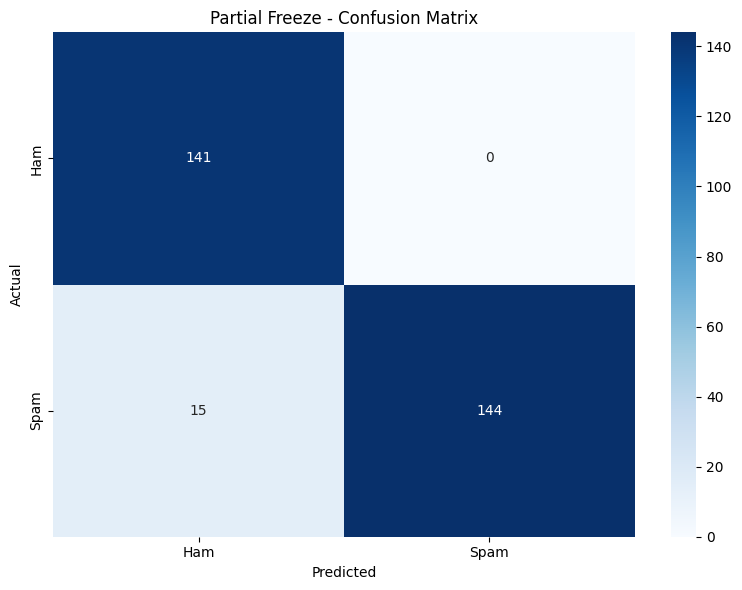


Confusion Matrix Breakdown:
  True Negatives (Ham->Ham):     141
  False Positives (Ham->Spam):   0
  False Negatives (Spam->Ham):   15
  True Positives (Spam->Spam):   144


Full Fine-tuning Model:


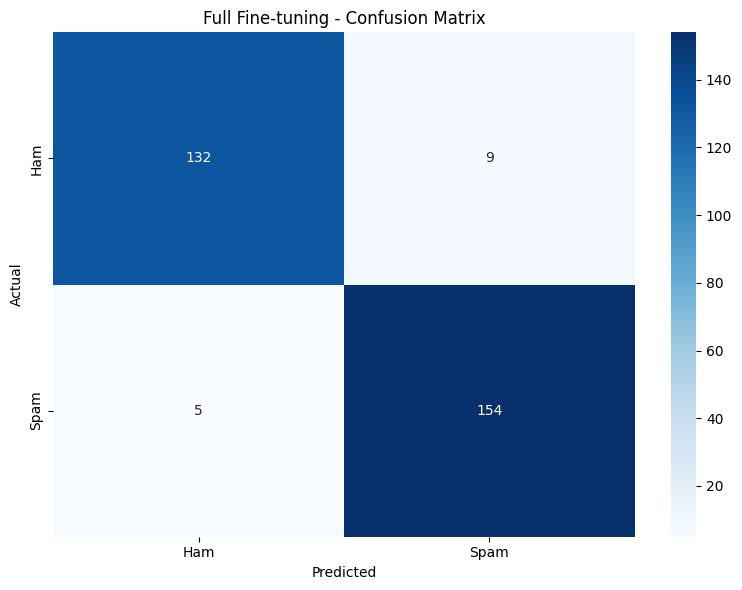


Confusion Matrix Breakdown:
  True Negatives (Ham->Ham):     132
  False Positives (Ham->Spam):   9
  False Negatives (Spam->Ham):   5
  True Positives (Spam->Spam):   154


In [55]:
def plot_confusion_matrix(preds, labels, title="Confusion Matrix"):
    """Plot a confusion matrix using seaborn."""
    cm = confusion_matrix(labels, preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    # Print breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix Breakdown:")
    print(f"  True Negatives (Ham->Ham):     {tn}")
    print(f"  False Positives (Ham->Spam):   {fp}")
    print(f"  False Negatives (Spam->Ham):   {fn}")
    print(f"  True Positives (Spam->Spam):   {tp}")
    
    return cm


# Plot confusion matrices for both models
print("Partial Freeze Model:")
cm_frozen = plot_confusion_matrix(preds_frozen, labels_frozen, "Partial Freeze - Confusion Matrix")

print("\n\nFull Fine-tuning Model:")
cm_full = plot_confusion_matrix(preds_full, labels_full, "Full Fine-tuning - Confusion Matrix")

## 14. Error Analysis


In [56]:
def analyze_errors(model, data_loader, dataset_texts, indices, device, model_name="Model"):
    """Analyze misclassified examples."""
    model.eval()
    
    errors = {
        'false_positives': [],  # Predicted spam, but actually ham
        'false_negatives': []   # Predicted ham, but actually spam
    }
    
    idx = 0
    with torch.no_grad():
        for input_batch, target_batch in data_loader:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            
            logits = model(input_batch)[:, -1, :]
            preds = torch.argmax(logits, dim=-1)
            
            for pred, label in zip(preds.cpu(), target_batch.cpu()):
                original_idx = indices[idx]
                text = dataset_texts[original_idx]
                
                if pred.item() == 1 and label.item() == 0:  # False positive
                    errors['false_positives'].append({
                        'text': text,
                        'predicted': 'spam',
                        'actual': 'ham'
                    })
                elif pred.item() == 0 and label.item() == 1:  # False negative
                    errors['false_negatives'].append({
                        'text': text,
                        'predicted': 'ham', 
                        'actual': 'spam'
                    })
                    
                idx += 1
    
    print(f"\n{'='*60}")
    print(f"{model_name} Error Analysis")
    print(f"{'='*60}")
    
    print(f"\nFalse Positives (Ham misclassified as Spam): {len(errors['false_positives'])}")
    print("-" * 40)
    for i, err in enumerate(errors['false_positives'][:3]):  # Show first 3
        print(f"{i+1}. '{err['text'][:100]}...'")
    
    print(f"\nFalse Negatives (Spam misclassified as Ham): {len(errors['false_negatives'])}")
    print("-" * 40)
    for i, err in enumerate(errors['false_negatives'][:3]):  # Show first 3
        print(f"{i+1}. '{err['text'][:100]}...'")
    
    return errors


# For error analysis, we need the original texts and indices
# Get test set indices
n_train = int(len(balanced_df) * 0.70)
n_val = int(len(balanced_df) * 0.10)
test_indices = list(range(n_train + n_val, len(balanced_df)))
all_texts = balanced_df["Text"].tolist()

# Analyze errors for both models
errors_frozen = analyze_errors(
    model_frozen, test_loader, all_texts, test_indices, device, "Partial Freeze Model"
)
errors_full = analyze_errors(
    model_full, test_loader, all_texts, test_indices, device, "Full Fine-tuning Model"
)


Partial Freeze Model Error Analysis

False Positives (Ham misclassified as Spam): 0
----------------------------------------

False Negatives (Spam misclassified as Ham): 15
----------------------------------------
1. 'We live in the next  &lt;#&gt; mins...'
2. '1st wk FREE! Gr8 tones str8 2 u each wk. Txt NOKIA ON to 8007 for Classic Nokia tones or HIT ON to 8...'
3. 'Love isn't a decision, it's a feeling. If we could decide who to love, then, life would be much simp...'

Full Fine-tuning Model Error Analysis

False Positives (Ham misclassified as Spam): 9
----------------------------------------
1. 'Want to funk up ur fone with a weekly new tone reply TONES2U 2 this text. www.ringtones.co.uk, the o...'
2. 'URGENT! Your Mobile number has been awarded with a £2000 Bonus Caller Prize. Call 09058095201 from l...'
3. 'Do u konw waht is rael FRIENDSHIP Im gving yuo an exmpel: Jsut ese tihs msg.. Evrey splleing of tihs...'

False Negatives (Spam misclassified as Ham): 5
-------------------

## 15. Training Curves Visualization

Let's visualize the training progress by plotting loss and accuracy curves for both training approaches.

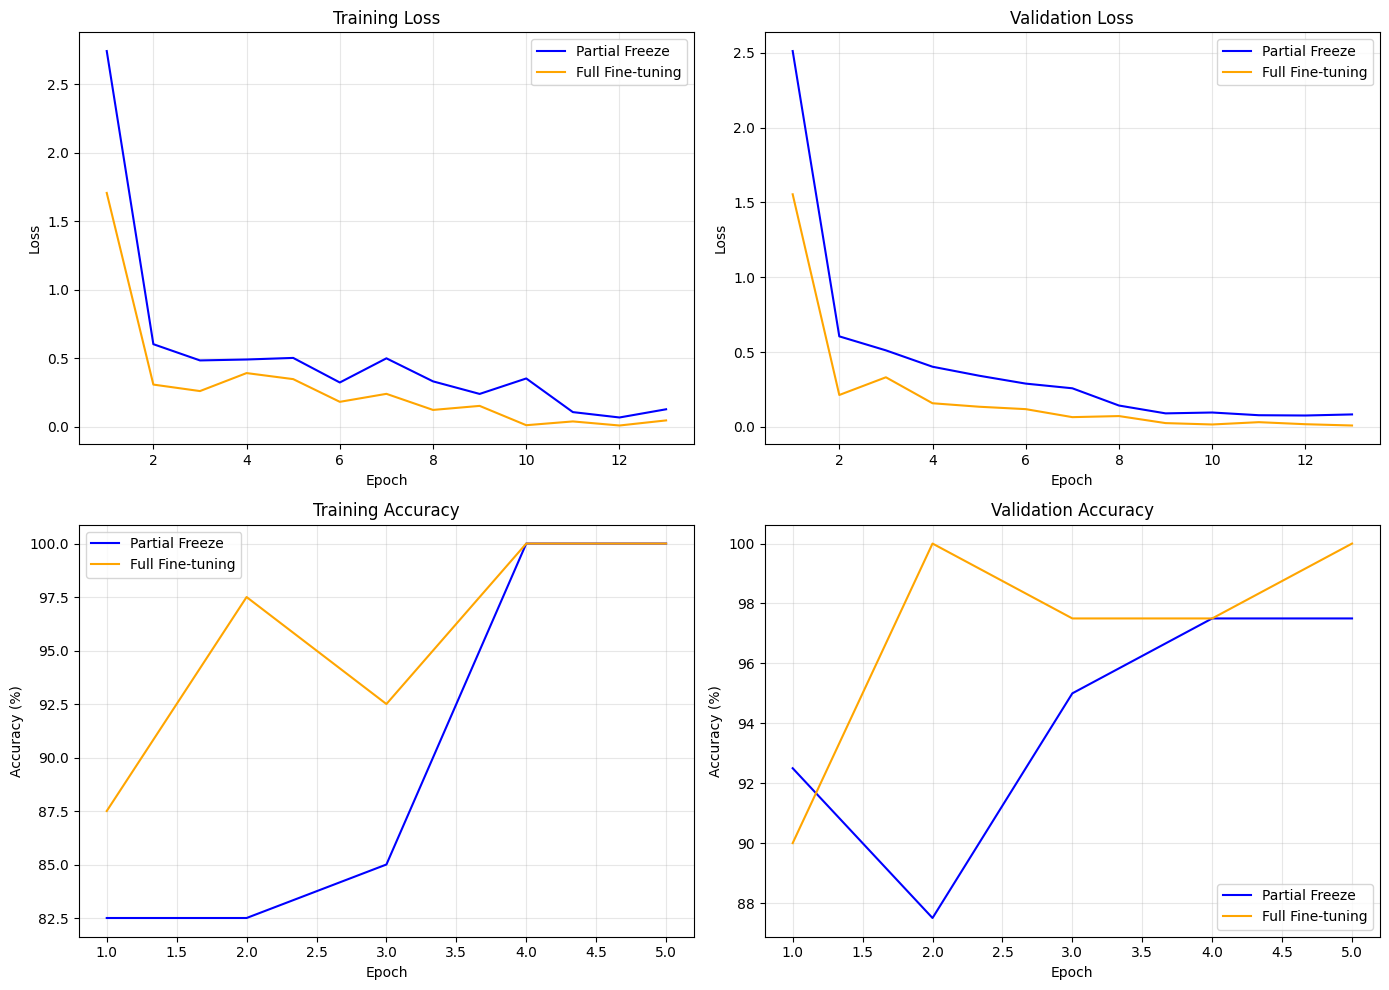


Training curves saved to 'training_curves.png'


In [57]:
def plot_training_curves(histories, labels, title_prefix=""):
    """Plot training and validation curves for multiple models."""
    _, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = ['blue', 'orange']
    
    # Training Loss
    ax = axes[0, 0]
    for history, label, color in zip(histories, labels, colors):
        epochs = range(1, len(history['train_losses']) + 1)
        ax.plot(epochs, history['train_losses'], f'-', color=color, label=f'{label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{title_prefix}Training Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Validation Loss
    ax = axes[0, 1]
    for history, label, color in zip(histories, labels, colors):
        epochs = range(1, len(history['val_losses']) + 1)
        ax.plot(epochs, history['val_losses'], f'-', color=color, label=f'{label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{title_prefix}Validation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Training Accuracy
    ax = axes[1, 0]
    for history, label, color in zip(histories, labels, colors):
        epochs = range(1, len(history['train_accs']) + 1)
        ax.plot(epochs, [acc * 100 for acc in history['train_accs']], f'-', color=color, label=f'{label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{title_prefix}Training Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Validation Accuracy
    ax = axes[1, 1]
    for history, label, color in zip(histories, labels, colors):
        epochs = range(1, len(history['val_accs']) + 1)
        ax.plot(epochs, [acc * 100 for acc in history['val_accs']], f'-', color=color, label=f'{label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{title_prefix}Validation Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nTraining curves saved to 'training_curves.png'")


# Plot comparison
plot_training_curves(
    [results_frozen, results_full],
    ['Partial Freeze', 'Full Fine-tuning'],
    ''
)

## 16. Model Comparison Summary

In [58]:
def count_trainable_params(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_total_params(model):
    """Count total parameters in a model."""
    return sum(p.numel() for p in model.parameters())


# Create comparison dataframe
comparison_data = {
    'Metric': [
        'Test Accuracy',
        'Precision', 
        'Recall',
        'F1-Score',
        'Final Train Loss',
        'Final Val Loss',
        'Training Time (approx)',
        'Trainable Parameters'
    ],
    'Partial Freeze': [
        f"{metrics_frozen['accuracy']:.4f}",
        f"{metrics_frozen['precision']:.4f}",
        f"{metrics_frozen['recall']:.4f}",
        f"{metrics_frozen['f1']:.4f}",
        f"{results_frozen['train_losses'][-1]:.4f}",
        f"{results_frozen['val_losses'][-1]:.4f}",
        f"~{len(results_frozen['train_losses'])} epochs",
        "~8M (last block + head)"
    ],
    'Full Fine-tuning': [
        f"{metrics_full['accuracy']:.4f}",
        f"{metrics_full['precision']:.4f}",
        f"{metrics_full['recall']:.4f}",
        f"{metrics_full['f1']:.4f}",
        f"{results_full['train_losses'][-1]:.4f}",
        f"{results_full['val_losses'][-1]:.4f}",
        f"~{len(results_full['train_losses'])} epochs",
        "~124M (all parameters)"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("COMPARISON: Partial Freeze vs Full Fine-tuning")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Determine winner for each metric (higher is better for accuracy, precision, recall, F1)
print("\n\nKey Insights:")
print("-" * 50)

acc_frozen = metrics_frozen['accuracy']
acc_full = metrics_full['accuracy']
if acc_frozen > acc_full:
    print(f"• Partial freeze achieves {(acc_frozen - acc_full)*100:.2f}% higher accuracy")
elif acc_full > acc_frozen:
    print(f"• Full fine-tuning achieves {(acc_full - acc_frozen)*100:.2f}% higher accuracy")
else:
    print(f"• Both approaches achieve equal accuracy")

f1_frozen = metrics_frozen['f1']
f1_full = metrics_full['f1']
if f1_frozen > f1_full:
    print(f"• Partial freeze has {(f1_frozen - f1_full)*100:.2f}% higher F1-score")
elif f1_full > f1_frozen:
    print(f"• Full fine-tuning has {(f1_full - f1_frozen)*100:.2f}% higher F1-score")
else:
    print(f"• Both approaches have equal F1-score")

print(f"\n• Partial freeze trains fewer parameters, making it more efficient")
print(f"• Full fine-tuning may overfit on small datasets like SMS Spam")
print(f"• Both approaches demonstrate effective transfer learning from GPT-2")


COMPARISON: Partial Freeze vs Full Fine-tuning
                Metric          Partial Freeze       Full Fine-tuning
         Test Accuracy                  0.9500                 0.9533
             Precision                  1.0000                 0.9448
                Recall                  0.9057                 0.9686
              F1-Score                  0.9505                 0.9565
      Final Train Loss                  0.1268                 0.0455
        Final Val Loss                  0.0830                 0.0090
Training Time (approx)              ~13 epochs             ~13 epochs
  Trainable Parameters ~8M (last block + head) ~124M (all parameters)


Key Insights:
--------------------------------------------------
• Full fine-tuning achieves 0.33% higher accuracy
• Full fine-tuning has 0.60% higher F1-score

• Partial freeze trains fewer parameters, making it more efficient
• Full fine-tuning may overfit on small datasets like SMS Spam
• Both approaches demonstrate

## 17. Save Model Checkpoints


In [59]:
# Save model checkpoints
torch.save({
    'model_state_dict': model_frozen.state_dict(),
    'config': BASE_CONFIG,
    'metrics': metrics_frozen,
    'history': results_frozen
}, 'spam_classifier_partial_freeze.pt')

torch.save({
    'model_state_dict': model_full.state_dict(),
    'config': BASE_CONFIG,
    'metrics': metrics_full,
    'history': results_full
}, 'spam_classifier_full_finetune.pt')

print("Models saved:")
print("  - spam_classifier_partial_freeze.pt")
print("  - spam_classifier_full_finetune.pt")

Models saved:
  - spam_classifier_partial_freeze.pt
  - spam_classifier_full_finetune.pt


## 18. Interactive Spam Classification Demo

Test the trained model on custom messages.

In [60]:
def classify_message(text, model, tokenizer, device, max_length=None):
    """Classify a single message as spam or ham."""
    model.eval()
    
    if max_length is None:
        max_length = model.pos_emb.weight.shape[0]
    
    # Tokenize
    token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    
    # Truncate if necessary
    if len(token_ids) > max_length:
        token_ids = token_ids[:max_length]
    
    # Pad
    PAD_TOKEN_ID = 50256
    padded = token_ids + [PAD_TOKEN_ID] * (max_length - len(token_ids))
    
    # Create tensor
    input_tensor = torch.tensor([padded], device=device)
    
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        prob = probs[0, 1].item()  # Get probability of class 1 (spam)
        prediction = 1 if prob > 0.5 else 0
    
    return {
        'text': text,
        'prediction': 'SPAM' if prediction == 1 else 'HAM',
        'spam_probability': prob,
        'confidence': max(prob, 1 - prob)
    }


# Test messages
test_messages = [
    "Hey, are you coming to the party tonight?",
    "CONGRATULATIONS! You've won £1000000! Click here to claim NOW!",
    "Meeting rescheduled to 3pm tomorrow. See you there.",
    "FREE entry in 2 a weekly comp to win FA Cup final tkts. Text FA to 87121",
    "Can you pick up some milk on your way home?",
    "Ur going 2 cum 2nite & hav a gr8 time. Call 09066382422 NOW 4 detail",
]

print("Spam Classification Demo (using Full Fine-tuning Model)")
print("=" * 60)

for msg in test_messages:
    result = classify_message(msg, model_full, tokenizer, device, max_length=256)
    confidence_bar = "█" * int(result['confidence'] * 20) + "░" * (20 - int(result['confidence'] * 20))
    print(f"\nMessage: '{msg[:50]}...'") if len(msg) > 50 else print(f"\nMessage: '{msg}'")
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: [{confidence_bar}] {result['confidence']*100:.1f}%")

Spam Classification Demo (using Full Fine-tuning Model)

Message: 'Hey, are you coming to the party tonight?'
Prediction: HAM
Confidence: [███████████████████░] 99.6%

Message: 'CONGRATULATIONS! You've won £1000000! Click here t...'
Prediction: HAM
Confidence: [████████████░░░░░░░░] 64.9%

Message: 'Meeting rescheduled to 3pm tomorrow. See you there...'
Prediction: HAM
Confidence: [███████████████████░] 95.7%

Message: 'FREE entry in 2 a weekly comp to win FA Cup final ...'
Prediction: HAM
Confidence: [██████████████░░░░░░] 74.2%

Message: 'Can you pick up some milk on your way home?'
Prediction: HAM
Confidence: [███████████████████░] 99.9%

Message: 'Ur going 2 cum 2nite & hav a gr8 time. Call 090663...'
Prediction: SPAM
Confidence: [███████████████████░] 96.1%
